# Data Processing for MCC5-THU Dataset

- Journal paper: https://www.sciencedirect.com/science/article/pii/S2352340924004220
- Data in Brief: https://arxiv.org/pdf/2403.12521
- Mendeley Data: https://data.mendeley.com/datasets/p92gj2732w/2
- GitHub\_ https://github.com/liuzy0708/MCC5-THU-Gearbox-Benchmark-Datasets

**ERRORS**

_Suffix `ERROR_` added to these files to make skipping easier\_

- gear_pitting_M_speed_circulation_20Nm-1000rpm.csv - Distortion, gain error, or something
- gear_pitting_M_torque_circulation_2000rpm_10Nm.csv - Distortion, gain error, or something

**Other notes**

Speeds seem to be +/- 50 RPM from the reported ones, but highest discrepancy is almost 150 RPM.

**V1**

- Step size 2 or 5

**V2**

- Step size 2
- Dropped `sample_index`


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from signal_analysis import FFT_TSA, order_track_FFT, order_track_signal, signal_TSA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from scipy.interpolate import CubicSpline, interp1d, InterpolatedUnivariateSpline

In [ ]:
def order_track_signal_MCC5(sig, tacho, time, num_samples_per_revolution):
    tacho_threshold = 3
    # num_samples_per_revolution = 360
    tacho_component_ratio = 29 / 95

    # Tachometer leading edge used as reference
    crossings = np.where(
        np.logical_and(tacho[:-1] <= tacho_threshold, tacho[1:] > tacho_threshold)
    )[0]

    # Angles at crossings
    crossing_angles = np.arange(len(crossings)) * 360
    # Angles at fault location
    crossing_angles_at_fault = crossing_angles / tacho_component_ratio

    # Only keep crossing angles at fault component within the range of original crossings
    crossing_angles_at_fault = crossing_angles_at_fault[
        crossing_angles_at_fault <= crossing_angles[-1]
    ]

    # Interpolate to find times at fault crossings
    t_crossings_at_fault = np.interp(
        crossing_angles_at_fault, crossing_angles, time[crossings]
    )

    # Essentially upsamples the time crossings to get the order tracked time points
    ot_interpolation_times = np.interp(
        np.arange((len(t_crossings_at_fault) - 1) * num_samples_per_revolution),
        np.arange(len(t_crossings_at_fault)) * num_samples_per_revolution,
        t_crossings_at_fault,
    )

    # Interpolate signal to new time points
    cs = CubicSpline(time, sig)
    ot_signal = cs(ot_interpolation_times)

    return ot_signal, ot_interpolation_times


# https://github.com/andrek10/bearing-vibration-diagnostics-toolbox/blob/master/pyvib/signal.py
def ordertrack_pyvib(t, y, tacho, ds, cubic=True):
    """
        Order track the vibration signal to match a desired position vector

        Parameters
        ----------
    t : float 1D array
        Time signal
    y : float 1D array
        Signal to order track
    ds : float
        Desired delta position
    cubic : boolean, optional
        Whether cubic interpolation is used

        Returns
        -------
    s_ot : float 1D array
        Shaft position of returned signal
    y_ot : float 1D array
        Order tracked signal
    """

    # Copy data
    t = np.array(t)
    y = np.array(y)
    t_s = t

    # NOTE: Start my changes
    crossings = np.where(np.logical_and(tacho[:-1] <= 3, tacho[1:] > 3))[0]

    start_idx = crossings[0]
    end_idx = crossings[-1]

    # Not actually angle but % of revolution
    crossings_angle = np.arange(len(crossings))
    input_shaft_position = np.interp(
        t[start_idx:end_idx], t[crossings], crossings_angle
    )
    s = input_shaft_position * (29 / 95)

    t = t[start_idx:end_idx]
    t_s = t_s[start_idx:end_idx]
    y = y[start_idx:end_idx]

    # NOTE: End my changes

    # Parameters
    dt = t[1] - t[0]

    # Get the overlapping parts between y and s
    temp = t[0]
    t = t - temp
    t_s = t_s - temp
    i1 = 0
    i2 = t.size
    if t_s[0] > 0.0:
        i1 = int(np.ceil(t_s[0] / dt))
    if t_s[-1] < t[-1]:
        i2 = int(np.floor(t_s[-1] / dt))
    t = t[i1:i2]
    y = y[i1:i2]

    # Interpolate the measured position to match vibration time
    f = interp1d(t_s, s)
    s = f(t)

    # Make desired position signal
    s_ot = np.arange(s[0], s[-1], ds)

    # print('s.size=%i, y.size=%i' % (s.size, y.size))

    # Make order tracked signal
    if cubic is True:
        f = InterpolatedUnivariateSpline(s, y, k=3)
    else:
        f = interp1d(s, y)
    y_ot = f(s_ot)

    s_ot = s_ot[s_ot < np.floor(s_ot[-1])]  # Only get full revolutions
    y_ot = y_ot[: s_ot.size]

    # Return data
    return y_ot, s_ot

In [ ]:
# SAMPLE OF DATA

data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
files = data_folder.glob("*.csv")

# Read the CSV files into a list of DataFrames
dataframes = []
df = pd.read_csv(next(files))
df.head(3)

## V3


In [ ]:
sampling_rate = 12800  # Hz
pinion_teeth = 36
first_gear_ratio = 29 / 95  # Ratio of first gear in the drivetrain

speed_cycle_map = {
    1000: 500,
    2000: 1500,
    3000: 2500,
}
torque_cycle_map = {
    10: 5,
    20: 15,
}

fault_map = {
    "teeth_crack": "crack",
    "gear_wear": "wear",
    "gear_pitting": "pitting",
    "miss_teeth": "missing_tooth",
    "teeth_break": "broken_tooth",
}

severity_map = {
    "L": "S",
    "M": "M",
    "H": "L",
    "XL": "XL",
}

# OT
# At 3000 RPM, there are ~838 samples per revolution of the pinion
# 36 (num pinion teeth) * 23 = 828 < 838, but over 11 * 36 * 2 = 792,
# which is the number of orders we want to track
num_samples_per_revolution = pinion_teeth * 23

# TSA
revolutions_per_TSA = 30
# revolutions_per_TSA = 15
TSA_step_size = 2
# Seconds to cut out for accelerations and deaccelerations
margin = 0.5

# Raw data
data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
files = data_folder.glob("*.csv")

dfs = []
for f in files:
    print(f)

    # SPECS
    ##

    # Get measurement specifications from file path
    p = f.stem.split("_")

    # Skip files with something wrong in them
    if p[0] == "ERROR":
        continue

    # Healthy
    if p[0] == "health":
        fault = "healthy"
        level = "-"

        # Which condition is cycled
        if f"{p[1]}_{p[2]}" == "torque_circulation":
            circulation = "torque"
            rpm = int(p[3].replace("rpm", ""))
            torque = int(p[4].replace("Nm", ""))
        elif f"{p[1]}_{p[2]}" == "speed_circulation":
            circulation = "speed"
            torque, rpm = p[3].split("-")
            torque = int(torque.replace("Nm", ""))
            rpm = int(rpm.replace("rpm", ""))
    # Faulty
    else:
        fault = f"{p[0]}_{p[1]}"

        # Skip other faults for now
        if fault not in fault_map or p[2] == "and":
            continue

        fault = fault_map[fault]
        if fault == "missing_tooth":
            # NOTE: Missing tooth doesn't have severity.
            p.insert(2, "L")
            fault = "missing_tooth"

        level = severity_map[p[2]]  # L/M/H -> S/M/L

        # Which condition is cycled
        if f"{p[3]}_{p[4]}" == "torque_circulation":
            circulation = "torque"
            rpm = int(p[5].replace("rpm", ""))
            torque = int(p[6].replace("Nm", ""))
        elif f"{p[3]}_{p[4]}" == "speed_circulation":
            circulation = "speed"
            torque, rpm = p[5].split("-")
            torque = int(torque.replace("Nm", ""))
            rpm = int(rpm.replace("rpm", ""))
        else:
            continue

    print(fault, level, circulation, rpm, torque)

    # SIGNAL
    ##

    df = pd.read_csv(f)

    # Create estimated angle
    tacho = df["speed"].to_numpy()
    # tacho = (tacho > 2) * 1  # clean (* 1 to ensure int, not boolean)
    crossing_idxs = np.where(np.diff(tacho) == 1)[0]

    # Check that speed matches the one in the filename
    # Only check upper bound, because of changing speed
    rot_freq = sampling_rate / np.diff(crossing_idxs)
    wrong_speeds = rot_freq * 60 > rpm + 150
    if np.sum(wrong_speeds) > 0:
        print(f"Speed does not match ({rpm} vs {np.max(rot_freq) * 60}) in {f.parts}")

    # # print(len(crossing_idxs))
    # angle = np.arange(len(crossing_idxs)) * 360 * first_gear_ratio

    # # ! Endings are incorrect because of extrapolation, but they get cut out
    # interpolated_angle = np.interp(np.arange(len(tacho)), crossing_idxs, angle)

    tacho_part_1 = tacho[
        int((10 + margin) * sampling_rate) : int((20 - margin) * sampling_rate)
    ]
    tacho_part_2 = tacho[
        int((25 + margin) * sampling_rate) : int((35 - margin) * sampling_rate)
    ]
    tacho_part_3 = tacho[
        int((40 + margin) * sampling_rate) : int((50 - margin) * sampling_rate)
    ]

    # SIGNAL OT
    ##

    per_sensor_samples_SIGNAL_OT = []
    for sensor in [
        "motor_vibration_x",
        "motor_vibration_y",
        "motor_vibration_z",
        "gearbox_vibration_x",
        "gearbox_vibration_y",
        "gearbox_vibration_z",
    ]:
        # Cut out accelerations and deaccelerations
        part1 = df[sensor].to_numpy()[
            int((10 + margin) * sampling_rate) : int((20 - margin) * sampling_rate)
        ]
        part2 = df[sensor].to_numpy()[
            int((25 + margin) * sampling_rate) : int((35 - margin) * sampling_rate)
        ]
        part3 = df[sensor].to_numpy()[
            int((40 + margin) * sampling_rate) : int((50 - margin) * sampling_rate)
        ]

        # NOTE: Check that the values are not too high
        for part_name, part in zip(["part1", "part2", "part3"], [part1, part2, part3]):
            max_value = np.max(np.abs(part))
            if max_value > 20:
                raise Exception(
                    f"{sensor} - {part_name} contains values over 20. Max absolute value: {max_value}"
                )

        # print("Signal", len(part2))

        signal_OT_1, _ = ordertrack_pyvib(
            np.arange(len(part1)) / sampling_rate,
            part1,
            tacho_part_1,
            1 / num_samples_per_revolution,
        )

        # signal_OT_1, _ = order_track_signal_MCC5(
        #     part1,
        #     tacho_part_1,
        #     np.arange(len(part1)) / sampling_rate,
        #     num_samples_per_revolution,
        # )
        signal_OT_2, _ = ordertrack_pyvib(
            np.arange(len(part2)) / sampling_rate,
            part2,
            tacho_part_2,
            1 / num_samples_per_revolution,
        )
        # signal_OT_2, _ = order_track_signal_MCC5(
        #     part2,
        #     tacho_part_2,
        #     np.arange(len(part2)) / sampling_rate,
        #     num_samples_per_revolution,
        # )
        signal_OT_3, _ = ordertrack_pyvib(
            np.arange(len(part3)) / sampling_rate,
            part3,
            tacho_part_3,
            1 / num_samples_per_revolution,
        )
        # signal_OT_3, _ = order_track_signal_MCC5(
        #     part3,
        #     tacho_part_3,
        #     np.arange(len(part3)) / sampling_rate,
        #     num_samples_per_revolution,
        # )

        signal_OT_TSA_1 = signal_TSA(
            signal_OT_1, num_samples_per_revolution, revolutions_per_TSA, TSA_step_size
        )
        signal_OT_TSA_2 = signal_TSA(
            signal_OT_2, num_samples_per_revolution, revolutions_per_TSA, TSA_step_size
        )
        signal_OT_TSA_3 = signal_TSA(
            signal_OT_3, num_samples_per_revolution, revolutions_per_TSA, TSA_step_size
        )

        TSA_FFTs_1 = np.abs(np.fft.rfft(signal_OT_TSA_1, norm="forward", axis=1))[
            :, : 11 * pinion_teeth
        ]
        if len(signal_OT_TSA_2) > 0:
            TSA_FFTs_2 = np.abs(np.fft.rfft(signal_OT_TSA_2, norm="forward", axis=1))[
                :, : 11 * pinion_teeth
            ]
        else:
            TSA_FFTs_2 = np.array([])
        TSA_FFTs_3 = np.abs(np.fft.rfft(signal_OT_TSA_3, norm="forward", axis=1))[
            :, : 11 * pinion_teeth
        ]

        TSA_FFTs_upper = np.concatenate((TSA_FFTs_1, TSA_FFTs_3), axis=0)

        per_sensor_samples_SIGNAL_OT.append({
            "upper": TSA_FFTs_upper.astype(np.float32),
            "lower": TSA_FFTs_2.astype(np.float32),
        })

    expanded_rows = []

    # Upper end measurements SIGNAL OT
    for j in range(per_sensor_samples_SIGNAL_OT[0]["upper"].shape[0]):
        expanded_rows.append({
            "speed": rpm,
            "load": torque,
            "severity": level,
            "class": fault,
            "circulation": "speed" if circulation == "speed" else "torque",
            "OT_method": "signal",
            "TSA_size": revolutions_per_TSA,
            # "sample_index": sample_i,
            "motor_vibration_x": per_sensor_samples_SIGNAL_OT[0]["upper"][j],
            "motor_vibration_y": per_sensor_samples_SIGNAL_OT[1]["upper"][j],
            "motor_vibration_z": per_sensor_samples_SIGNAL_OT[2]["upper"][j],
            "gearbox_vibration_x": per_sensor_samples_SIGNAL_OT[3]["upper"][j],
            "gearbox_vibration_y": per_sensor_samples_SIGNAL_OT[4]["upper"][j],
            "gearbox_vibration_z": per_sensor_samples_SIGNAL_OT[5]["upper"][j],
        })
        # sample_i += 1

    # Lower end measurements SIGNAL OT
    for j in range(per_sensor_samples_SIGNAL_OT[0]["lower"].shape[0]):
        expanded_rows.append({
            "speed": rpm if circulation == "torque" else speed_cycle_map[rpm],
            "load": (torque if circulation == "speed" else torque_cycle_map[torque]),
            "severity": level,
            "class": fault,
            "circulation": "speed" if circulation == "speed" else "torque",
            "OT_method": "signal",
            "TSA_size": revolutions_per_TSA,
            # "sample_index": sample_i,
            "motor_vibration_x": per_sensor_samples_SIGNAL_OT[0]["lower"][j],
            "motor_vibration_y": per_sensor_samples_SIGNAL_OT[1]["lower"][j],
            "motor_vibration_z": per_sensor_samples_SIGNAL_OT[2]["lower"][j],
            "gearbox_vibration_x": per_sensor_samples_SIGNAL_OT[3]["lower"][j],
            "gearbox_vibration_y": per_sensor_samples_SIGNAL_OT[4]["lower"][j],
            "gearbox_vibration_z": per_sensor_samples_SIGNAL_OT[5]["lower"][j],
        })
        # sample_i += 1

    # Make DF of one file
    dfs.append(pd.DataFrame(expanded_rows))

# Combine files
dfs = pd.concat(dfs)
dfs.head(3)

In [ ]:
# SAVING

dfs.to_feather(Path.cwd().parent.parent / "data" / "MCC5-THU_OT_V3.feather")
# dfs.to_feather(Path.cwd().parent.parent / "data" / "MCC5-THU_OT_TSA_15.feather")

## V2


In [ ]:
sampling_rate = 12800  # Hz
pinion_teeth = 36
first_gear_ratio = 29 / 95  # Ratio of first gear in the drivetrain

speed_cycle_map = {
    1000: 500,
    2000: 1500,
    3000: 2500,
}
torque_cycle_map = {
    10: 5,
    20: 15,
}

fault_map = {
    "teeth_crack": "crack",
    "gear_wear": "wear",
    "gear_pitting": "pitting",
    "miss_teeth": "missing_tooth",
    "teeth_break": "broken_tooth",
}

severity_map = {
    "L": "S",
    "M": "M",
    "H": "L",
    "XL": "XL",
}

# OT
# At 3000 RPM, there are ~838 samples per revolution of the pinion
# 36 (num pinion teeth) * 23 = 828 < 838, but over 11 * 36 * 2 = 792,
# which is the number of orders we want to track
num_samples_per_revolution = pinion_teeth * 23

# TSA
revolutions_per_TSA = 30
# revolutions_per_TSA = 15
TSA_step_size = 2
# Seconds to cut out for accelerations and deaccelerations
margin = 0.5

# Raw data
data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
files = data_folder.glob("*.csv")

dfs = []
for f in files:
    print(f)

    # SPECS
    ##

    # Get measurement specifications from file path
    p = f.stem.split("_")

    # Skip files with something wrong in them
    if p[0] == "ERROR":
        continue

    # Healthy
    if p[0] == "health":
        fault = "healthy"
        level = "-"

        # Which condition is cycled
        if f"{p[1]}_{p[2]}" == "torque_circulation":
            circulation = "torque"
            rpm = int(p[3].replace("rpm", ""))
            torque = int(p[4].replace("Nm", ""))
        elif f"{p[1]}_{p[2]}" == "speed_circulation":
            circulation = "speed"
            torque, rpm = p[3].split("-")
            torque = int(torque.replace("Nm", ""))
            rpm = int(rpm.replace("rpm", ""))
    # Faulty
    else:
        fault = f"{p[0]}_{p[1]}"

        # Skip other faults for now
        if fault not in fault_map.keys() or p[2] == "and":
            continue

        fault = fault_map[fault]
        if fault == "missing_tooth":
            # NOTE: Missing tooth doesn't have severity.
            # This converts it to a crack and makes the severity XL
            p.insert(2, "XL")
            fault = "crack"

        level = severity_map[p[2]]  # L/M/H -> S/M/L

        # Which condition is cycled
        if f"{p[3]}_{p[4]}" == "torque_circulation":
            circulation = "torque"
            rpm = int(p[5].replace("rpm", ""))
            torque = int(p[6].replace("Nm", ""))
        elif f"{p[3]}_{p[4]}" == "speed_circulation":
            circulation = "speed"
            torque, rpm = p[5].split("-")
            torque = int(torque.replace("Nm", ""))
            rpm = int(rpm.replace("rpm", ""))
        else:
            continue

    print(fault, level, circulation, rpm, torque)

    # SIGNAL
    ##

    df = pd.read_csv(f)

    # Create estimated angle
    tacho = df["speed"].to_numpy()
    tacho = (tacho > 2) * 1  # clean (* 1 to ensure int, not boolean)
    crossing_idxs = np.where(np.diff(tacho) == 1)[0]

    # Check that speed matches the one in the filename
    # Only check upper bound, because of changing speed
    rot_freq = sampling_rate / np.diff(crossing_idxs)
    wrong_speeds = rot_freq * 60 > rpm + 150
    if np.sum(wrong_speeds) > 0:
        print(f"Speed does not match ({rpm} vs {np.max(rot_freq) * 60}) in {f.parts}")

    # print(len(crossing_idxs))
    angle = np.arange(len(crossing_idxs)) * 360 * first_gear_ratio

    # ! Endings are incorrect because of extrapolation, but they get cut out
    interpolated_angle = np.interp(np.arange(len(tacho)), crossing_idxs, angle)

    angle_part_1 = interpolated_angle[
        int((10 + margin) * sampling_rate) : int((20 - margin) * sampling_rate)
    ]
    angle_part_2 = interpolated_angle[
        int((25 + margin) * sampling_rate) : int((35 - margin) * sampling_rate)
    ]
    angle_part_3 = interpolated_angle[
        int((40 + margin) * sampling_rate) : int((50 - margin) * sampling_rate)
    ]

    # FFT OT
    ##

    per_sensor_samples_FFT_OT = []
    for sensor in [
        "motor_vibration_x",
        "motor_vibration_y",
        "motor_vibration_z",
        "gearbox_vibration_x",
        "gearbox_vibration_y",
        "gearbox_vibration_z",
    ]:
        # Cut out accelerations and deaccelerations
        part1 = df[sensor].to_numpy()[
            int((10 + margin) * sampling_rate) : int((20 - margin) * sampling_rate)
        ]
        part2 = df[sensor].to_numpy()[
            int((25 + margin) * sampling_rate) : int((35 - margin) * sampling_rate)
        ]
        part3 = df[sensor].to_numpy()[
            int((40 + margin) * sampling_rate) : int((50 - margin) * sampling_rate)
        ]

        # print("Signal", len(part2))

        # OT
        FFTs_1 = order_track_FFT(
            part1, None, angle_part_1, num_orders=pinion_teeth * 11
        )
        FFTs_2 = order_track_FFT(
            part2, None, angle_part_2, num_orders=pinion_teeth * 11
        )
        FFTs_3 = order_track_FFT(
            part3, None, angle_part_3, num_orders=pinion_teeth * 11
        )

        TSA_FFTs_1 = FFT_TSA(FFTs_1, revolutions_per_TSA, TSA_step_size)
        TSA_FFTs_2 = FFT_TSA(FFTs_2, revolutions_per_TSA, TSA_step_size)
        TSA_FFTs_3 = FFT_TSA(FFTs_3, revolutions_per_TSA, TSA_step_size)

        TSA_FFTs_upper = np.concatenate((TSA_FFTs_1, TSA_FFTs_3), axis=0)

        per_sensor_samples_FFT_OT.append({
            "upper": TSA_FFTs_upper.astype(np.float32),
            "lower": TSA_FFTs_2.astype(np.float32),
        })

    # SIGNAL OT
    ##

    per_sensor_samples_SIGNAL_OT = []
    for sensor in [
        "motor_vibration_x",
        "motor_vibration_y",
        "motor_vibration_z",
        "gearbox_vibration_x",
        "gearbox_vibration_y",
        "gearbox_vibration_z",
    ]:
        # Cut out accelerations and deaccelerations
        part1 = df[sensor].to_numpy()[
            int((10 + margin) * sampling_rate) : int((20 - margin) * sampling_rate)
        ]
        part2 = df[sensor].to_numpy()[
            int((25 + margin) * sampling_rate) : int((35 - margin) * sampling_rate)
        ]
        part3 = df[sensor].to_numpy()[
            int((40 + margin) * sampling_rate) : int((50 - margin) * sampling_rate)
        ]

        # NOTE: Check that the values are not too high
        for part_name, part in zip(["part1", "part2", "part3"], [part1, part2, part3]):
            max_value = np.max(np.abs(part))
            if max_value > 20:
                raise Exception(
                    f"{sensor} - {part_name} contains values over 20. Max absolute value: {max_value}"
                )

        # print("Signal", len(part2))

        # OT
        # num_samples_per_revolution_1 = (
        #     int(sampling_rate / (rpm / 60 * first_gear_ratio)) + 50
        # )
        # lower_rpm = rpm if circulation == "torque" else speed_cycle_map[rpm]
        # num_samples_per_revolution_2 = (
        #     int(sampling_rate / (lower_rpm / 60 * first_gear_ratio)) + 50
        # )

        signal_OT_1 = order_track_signal(
            part1,
            np.arange(len(part1)) / sampling_rate,
            angle_part_1,
            num_samples_per_revolution,
        )
        signal_OT_2 = order_track_signal(
            part2,
            np.arange(len(part2)) / sampling_rate,
            angle_part_2,
            num_samples_per_revolution,
        )
        signal_OT_3 = order_track_signal(
            part3,
            np.arange(len(part3)) / sampling_rate,
            angle_part_3,
            num_samples_per_revolution,
        )

        signal_OT_TSA_1 = signal_TSA(
            signal_OT_1, num_samples_per_revolution, revolutions_per_TSA, TSA_step_size
        )
        signal_OT_TSA_2 = signal_TSA(
            signal_OT_2, num_samples_per_revolution, revolutions_per_TSA, TSA_step_size
        )
        signal_OT_TSA_3 = signal_TSA(
            signal_OT_3, num_samples_per_revolution, revolutions_per_TSA, TSA_step_size
        )

        TSA_FFTs_1 = np.abs(np.fft.rfft(signal_OT_TSA_1, norm="forward", axis=1))[
            :, : 11 * pinion_teeth
        ]
        if len(signal_OT_TSA_2) > 0:
            TSA_FFTs_2 = np.abs(np.fft.rfft(signal_OT_TSA_2, norm="forward", axis=1))[
                :, : 11 * pinion_teeth
            ]
        else:
            TSA_FFTs_2 = np.array([])
        TSA_FFTs_3 = np.abs(np.fft.rfft(signal_OT_TSA_3, norm="forward", axis=1))[
            :, : 11 * pinion_teeth
        ]

        TSA_FFTs_upper = np.concatenate((TSA_FFTs_1, TSA_FFTs_3), axis=0)

        per_sensor_samples_SIGNAL_OT.append({
            "upper": TSA_FFTs_upper.astype(np.float32),
            "lower": TSA_FFTs_2.astype(np.float32),
        })

    expanded_rows = []
    # sample_i = 0
    # Upper end measurements FFT OT
    for j in range(per_sensor_samples_FFT_OT[0]["upper"].shape[0]):
        expanded_rows.append({
            "speed": rpm,
            "load": torque,
            "severity": level,
            "class": fault,
            "circulation": "speed" if circulation == "speed" else "torque",
            "OT_method": "fft",
            "TSA_size": revolutions_per_TSA,
            # "sample_index": sample_i,
            "motor_vibration_x": per_sensor_samples_FFT_OT[0]["upper"][j],
            "motor_vibration_y": per_sensor_samples_FFT_OT[1]["upper"][j],
            "motor_vibration_z": per_sensor_samples_FFT_OT[2]["upper"][j],
            "gearbox_vibration_x": per_sensor_samples_FFT_OT[3]["upper"][j],
            "gearbox_vibration_y": per_sensor_samples_FFT_OT[4]["upper"][j],
            "gearbox_vibration_z": per_sensor_samples_FFT_OT[5]["upper"][j],
        })
        # sample_i += 1

    # Upper end measurements SIGNAL OT
    for j in range(per_sensor_samples_SIGNAL_OT[0]["upper"].shape[0]):
        expanded_rows.append({
            "speed": rpm,
            "load": torque,
            "severity": level,
            "class": fault,
            "circulation": "speed" if circulation == "speed" else "torque",
            "OT_method": "signal",
            "TSA_size": revolutions_per_TSA,
            # "sample_index": sample_i,
            "motor_vibration_x": per_sensor_samples_SIGNAL_OT[0]["upper"][j],
            "motor_vibration_y": per_sensor_samples_SIGNAL_OT[1]["upper"][j],
            "motor_vibration_z": per_sensor_samples_SIGNAL_OT[2]["upper"][j],
            "gearbox_vibration_x": per_sensor_samples_SIGNAL_OT[3]["upper"][j],
            "gearbox_vibration_y": per_sensor_samples_SIGNAL_OT[4]["upper"][j],
            "gearbox_vibration_z": per_sensor_samples_SIGNAL_OT[5]["upper"][j],
        })
        # sample_i += 1

    # sample_i = 0
    # # ! Leave out 500 rpm
    # effective_speed = rpm if circulation == "torque" else speed_cycle_map[rpm]
    # if effective_speed in [500]:
    #     continue

    # Lower end measurements FFT OT
    for j in range(per_sensor_samples_FFT_OT[0]["lower"].shape[0]):
        expanded_rows.append({
            "speed": rpm if circulation == "torque" else speed_cycle_map[rpm],
            "load": (torque if circulation == "speed" else torque_cycle_map[torque]),
            "severity": level,
            "class": fault,
            "circulation": "speed" if circulation == "speed" else "torque",
            "OT_method": "fft",
            "TSA_size": revolutions_per_TSA,
            # "sample_index": sample_i,
            "motor_vibration_x": per_sensor_samples_FFT_OT[0]["lower"][j],
            "motor_vibration_y": per_sensor_samples_FFT_OT[1]["lower"][j],
            "motor_vibration_z": per_sensor_samples_FFT_OT[2]["lower"][j],
            "gearbox_vibration_x": per_sensor_samples_FFT_OT[3]["lower"][j],
            "gearbox_vibration_y": per_sensor_samples_FFT_OT[4]["lower"][j],
            "gearbox_vibration_z": per_sensor_samples_FFT_OT[5]["lower"][j],
        })
        # sample_i += 1

    # Lower end measurements SIGNAL OT
    for j in range(per_sensor_samples_SIGNAL_OT[0]["lower"].shape[0]):
        expanded_rows.append({
            "speed": rpm if circulation == "torque" else speed_cycle_map[rpm],
            "load": (torque if circulation == "speed" else torque_cycle_map[torque]),
            "severity": level,
            "class": fault,
            "circulation": "speed" if circulation == "speed" else "torque",
            "OT_method": "signal",
            "TSA_size": revolutions_per_TSA,
            # "sample_index": sample_i,
            "motor_vibration_x": per_sensor_samples_SIGNAL_OT[0]["lower"][j],
            "motor_vibration_y": per_sensor_samples_SIGNAL_OT[1]["lower"][j],
            "motor_vibration_z": per_sensor_samples_SIGNAL_OT[2]["lower"][j],
            "gearbox_vibration_x": per_sensor_samples_SIGNAL_OT[3]["lower"][j],
            "gearbox_vibration_y": per_sensor_samples_SIGNAL_OT[4]["lower"][j],
            "gearbox_vibration_z": per_sensor_samples_SIGNAL_OT[5]["lower"][j],
        })
        # sample_i += 1

    # Make DF of one file
    dfs.append(pd.DataFrame(expanded_rows))

# Combine files
dfs = pd.concat(dfs)
dfs.head(3)

In [ ]:
dfs.dtypes

In [ ]:
# SAVING

dfs.to_feather(Path.cwd().parent.parent / "data" / "MCC5-THU_OT_V2.feather")
# dfs.to_feather(Path.cwd().parent.parent / "data" / "MCC5-THU_OT_TSA_15.feather")

In [ ]:
pd.options.display.max_rows = 120
dfs.groupby(["class", "speed", "load", "severity"]).count()
dfs[dfs["class"] == "crack"].groupby(["class", "speed", "load", "severity"]).count()

## Testing


,speed,torque,motor_vibration_x,motor_vibration_y,motor_vibration_z,gearbox_vibration_x,gearbox_vibration_y,gearbox_vibration_z
0,3.816603,0.155079,-0.040293,-0.010240,0.011194,-0.003111,0.000060,-0.002003
1,3.456001,0.176841,-0.022209,0.008249,0.015998,-0.018239,-0.017715,-0.001860
2,3.700651,0.133699,-0.014019,0.000822,0.011826,-0.019228,-0.022435,0.011289
3,3.576634,0.196576,-0.024128,0.001586,0.011516,-0.015080,-0.015712,0.012076
4,3.558455,0.216734,-0.012922,0.000262,0.010753,-0.010550,-0.007677,-0.000441
...,...,...,...,...,...,...,...,...
767994,-0.000836,0.623250,-0.579178,-0.730371,6.010127,-0.995040,0.407565,-0.330138
767995,0.004857,0.636536,0.164282,0.291777,-1.795018,-1.121926,0.071359,-0.037014
767996,0.004950,0.526375,0.558579,0.489640,-6.148899,-0.318372,-0.723541,-0.074947
767997,0.000921,0.590086,-0.503087,-0.255704,2.366781,0.168526,-0.937975,0.168502


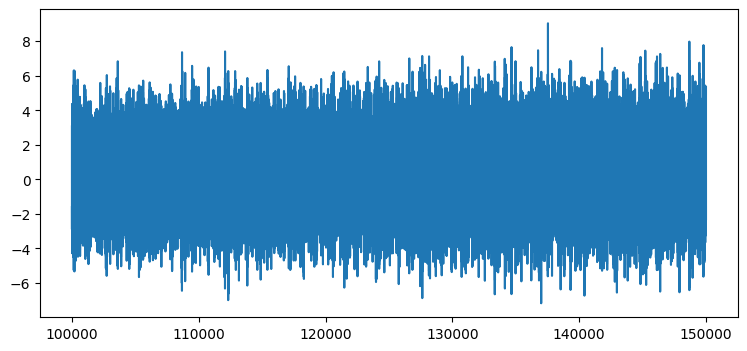

In [ ]:
data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
df = pd.read_csv(data_folder / "teeth_crack_H_torque_circulation_3000rpm_20Nm.csv")
# df = pd.read_csv(data_folder / "gear_wear_H_torque_circulation_3000rpm_20Nm.csv")
# df = pd.read_csv(data_folder / "ERROR_gear_pitting_M_torque_circulation_2000rpm_10Nm.csv")

# plt.plot(df["speed"])
plt.subplots(figsize=(9, 4))
plt.plot(df["gearbox_vibration_y"][100000])
df

## Operating Condition Visualizations


In [ ]:
data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
df = pd.read_csv(data_folder / "gear_wear_H_speed_circulation_10Nm-1000rpm.csv")
df2 = pd.read_csv(data_folder / "gear_wear_H_speed_circulation_10Nm-2000rpm.csv")
# df

tacho = df["speed"].to_numpy()
tacho = (tacho > 2) * 1  # clean
crossing_idxs = np.where(np.diff(tacho) == 1)[0]

tacho2 = df2["speed"].to_numpy()
tacho2 = (tacho2 > 2) * 1  # clean
crossing_idxs2 = np.where(np.diff(tacho2) == 1)[0]

px.line(y=np.diff(crossing_idxs))

fig = px.line(title="gear_wear_H_speed_circulation_10Nm-1000rpm.csv [speed]")
fig = fig.add_scatter(
    y=np.diff(crossing_idxs), mode="lines", name="Revolution length [1000]"
)
fig = fig.add_scatter(
    y=1 / (np.diff(crossing_idxs) / 12800) * 60, mode="lines", name="RPM [1000]"
)
fig = fig.add_scatter(
    y=np.diff(crossing_idxs2), mode="lines", name="Revolution length [2000]"
)
fig = fig.add_scatter(
    y=1 / (np.diff(crossing_idxs2) / 12800) * 60, mode="lines", name="RPM [2000]"
)
fig.show("notebook")

In [ ]:
data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
df = pd.read_csv(data_folder / "gear_wear_H_speed_circulation_10Nm-1000rpm.csv")
# df

torque = df["torque"].to_numpy() * 6  # x6 because torque not measured at affected gear

fig = px.line(title="gear_wear_H_torque_circulation_1000rpm_20Nm.csv [torque]")
fig = fig.add_scatter(y=torque[::8], mode="lines", name="Torque")  #! Downsampled
fig.show("notebook")

In [ ]:
data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
df = pd.read_csv(data_folder / "gear_wear_H_torque_circulation_1000rpm_20Nm.csv")
# df

torque = df["torque"].to_numpy() * 6  #! x6 because torque not measured at affected gear

fig = px.line(title="gear_wear_H_torque_circulation_1000rpm_20Nm.csv [torque]")
fig = fig.add_scatter(y=torque, mode="lines", name="Torque")
fig.show("notebook")

In [ ]:
data_folder = Path.cwd().parent.parent.parent / "data" / "MCC5-THU"
df = pd.read_csv(data_folder / "gear_wear_H_torque_circulation_1000rpm_20Nm.csv")
# df

tacho = df["speed"].to_numpy()
tacho = (tacho > 2) * 1  # clean
crossing_idxs = np.where(np.diff(tacho) == 1)[0]

px.line(y=np.diff(crossing_idxs))

fig = px.line(title="gear_wear_H_speed_circulation_10Nm-1000rpm.csv [speed]")
fig = fig.add_scatter(y=np.diff(crossing_idxs), mode="lines", name="Revolution length")
fig = fig.add_scatter(
    y=1 / (np.diff(crossing_idxs) / 12800) * 60, mode="lines", name="RPM"
)
fig.show("notebook")

## Clustering Visualizations


In [ ]:
# fmt: off
A1 = np.stack(list(dfs[(dfs["fault"] == "teeth_crack") & (dfs["torque"] == 10) & (dfs["rpm"] == 1000) & (dfs["level"] == "L")]["gearbox_vibration_x"]))
A2 = np.stack(list(dfs[(dfs["fault"] == "teeth_crack") & (dfs["torque"] == 10) & (dfs["rpm"] == 1000) & (dfs["level"] == "H")]["gearbox_vibration_x"]))
A3 = np.stack(list(dfs[(dfs["fault"] == "teeth_crack") & (dfs["torque"] == 10) & (dfs["rpm"] == 2000) & (dfs["level"] == "L")]["gearbox_vibration_x"]))
A4 = np.stack(list(dfs[(dfs["fault"] == "teeth_crack") & (dfs["torque"] == 10) & (dfs["rpm"] == 2000) & (dfs["level"] == "H")]["gearbox_vibration_x"]))

B1 = np.stack(list(dfs[(dfs["fault"] == "gear_wear") & (dfs["torque"] == 10) & (dfs["rpm"] == 1000) & (dfs["level"] == "L")]["gearbox_vibration_x"]))
B2 = np.stack(list(dfs[(dfs["fault"] == "gear_wear") & (dfs["torque"] == 10) & (dfs["rpm"] == 1000) & (dfs["level"] == "H")]["gearbox_vibration_x"]))
B3 = np.stack(list(dfs[(dfs["fault"] == "gear_wear") & (dfs["torque"] == 10) & (dfs["rpm"] == 2000) & (dfs["level"] == "L")]["gearbox_vibration_x"]))
B4 = np.stack(list(dfs[(dfs["fault"] == "gear_wear") & (dfs["torque"] == 10) & (dfs["rpm"] == 2000) & (dfs["level"] == "H")]["gearbox_vibration_x"]))

C1 = np.stack(list(dfs[(dfs["fault"] == "baseline") & (dfs["torque"] == 10) & (dfs["rpm"] == 1000)]["gearbox_vibration_x"]))
C2 = np.stack(list(dfs[(dfs["fault"] == "baseline") & (dfs["torque"] == 10) & (dfs["rpm"] == 2000)]["gearbox_vibration_x"]))
# fmt: on

A1 = normalize(A1, norm="l2", axis=1)
A2 = normalize(A2, norm="l2", axis=1)
A3 = normalize(A3, norm="l2", axis=1)
A4 = normalize(A4, norm="l2", axis=1)
B1 = normalize(B1, norm="l2", axis=1)
B2 = normalize(B2, norm="l2", axis=1)
B3 = normalize(B3, norm="l2", axis=1)
B4 = normalize(B4, norm="l2", axis=1)
C1 = normalize(C1, norm="l2", axis=1)
C2 = normalize(C2, norm="l2", axis=1)

In [ ]:
pca = PCA(n_components=3)
pca_embeddings = pca.fit_transform(
    np.concatenate(
        [
            A1,
            A2,
            A3,
            A4,
            B1,
            B2,
            B3,
            B4,
            C1,
            C2,
        ],
        axis=0,
    )
)
pca_embeddings = pd.DataFrame(pca_embeddings, columns=["x", "y", "z"])

pca_embeddings["class"] = np.concatenate([
    len(A1) * ["Teeth crack"],
    len(A2) * ["Teeth crack"],
    len(A3) * ["Teeth crack"],
    len(A4) * ["Teeth crack"],
    len(B1) * ["Gear wear"],
    len(B2) * ["Gear wear"],
    len(B3) * ["Gear wear"],
    len(B4) * ["Gear wear"],
    len(C1) * ["Baseline"],
    len(C2) * ["Baseline"],
])
pca_embeddings["rpm"] = np.concatenate([
    len(A1) * [1000],
    len(A2) * [1000],
    len(A3) * [2000],
    len(A4) * [2000],
    len(B1) * [1000],
    len(B2) * [1000],
    len(B3) * [2000],
    len(B4) * [2000],
    len(C1) * [1000],
    len(C2) * [2000],
])

pca_embeddings["level"] = np.concatenate([
    len(A1) * ["L"],
    len(A2) * ["H"],
    len(A3) * ["L"],
    len(A4) * ["H"],
    len(B1) * ["L"],
    len(B2) * ["H"],
    len(B3) * ["L"],
    len(B4) * ["H"],
    len(C1) * ["-"],
    len(C2) * ["-"],
])

fig = px.scatter_3d(
    pca_embeddings,
    x="x",
    y="y",
    z="z",
    color="class",
    symbol="rpm",
    hover_data=["class", "rpm", "level"],
    width=800,
    height=800,
)

fig.update_layout(
    title=dict(text="PCA", font=dict(size=50), automargin=True, yref="paper")
)
fig.show()

In [ ]:
tsne_embeddings = TSNE(
    n_components=3, learning_rate="auto", init="random", perplexity=20
).fit_transform(
    np.concatenate(
        [
            A1,
            A2,
            A3,
            A4,
            B1,
            B2,
            B3,
            B4,
            C1,
            C2,
        ],
        axis=0,
    )
)

tsne_embeddings = pd.DataFrame(tsne_embeddings, columns=["x", "y", "z"])

tsne_embeddings["class"] = np.concatenate([
    len(A1) * ["Teeth crack"],
    len(A2) * ["Teeth crack"],
    len(A3) * ["Teeth crack"],
    len(A4) * ["Teeth crack"],
    len(B1) * ["Gear wear"],
    len(B2) * ["Gear wear"],
    len(B3) * ["Gear wear"],
    len(B4) * ["Gear wear"],
    len(C1) * ["Baseline"],
    len(C2) * ["Baseline"],
])
tsne_embeddings["rpm"] = np.concatenate([
    len(A1) * [1000],
    len(A2) * [1000],
    len(A3) * [2000],
    len(A4) * [2000],
    len(B1) * [1000],
    len(B2) * [1000],
    len(B3) * [2000],
    len(B4) * [2000],
    len(C1) * [1000],
    len(C2) * [2000],
])

tsne_embeddings["level"] = np.concatenate([
    len(A1) * ["L"],
    len(A2) * ["H"],
    len(A3) * ["L"],
    len(A4) * ["H"],
    len(B1) * ["L"],
    len(B2) * ["H"],
    len(B3) * ["L"],
    len(B4) * ["H"],
    len(C1) * ["-"],
    len(C2) * ["-"],
])

fig = px.scatter_3d(
    tsne_embeddings,
    x="x",
    y="y",
    z="z",
    color="class",
    symbol="rpm",
    hover_data=["class", "rpm", "level"],
    width=1400,
    height=800,
)

fig.update_layout(
    title=dict(text="TSNE", font=dict(size=50), automargin=True, yref="paper")
)
fig.show()